<a href="https://colab.research.google.com/github/GayathriPamarthi20/Unemployment-Analysis-with-Python/blob/main/Unemployment_Analysis_with_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload kaggle.json file


Saving ChatGPT.url to ChatGPT.url
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/gokulrajkmv/unemployment-in-india
License(s): other
100% 16.0k/16.0k [00:00<00:00, 44.1MB/s]

Dataset Extracted Successfully

Files:
['.config', 'unemployment-in-india.zip', 'Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv', 'ChatGPT.url', 'sample_data']

First 5 Rows:


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74



Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB

Missing Values
Region                

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


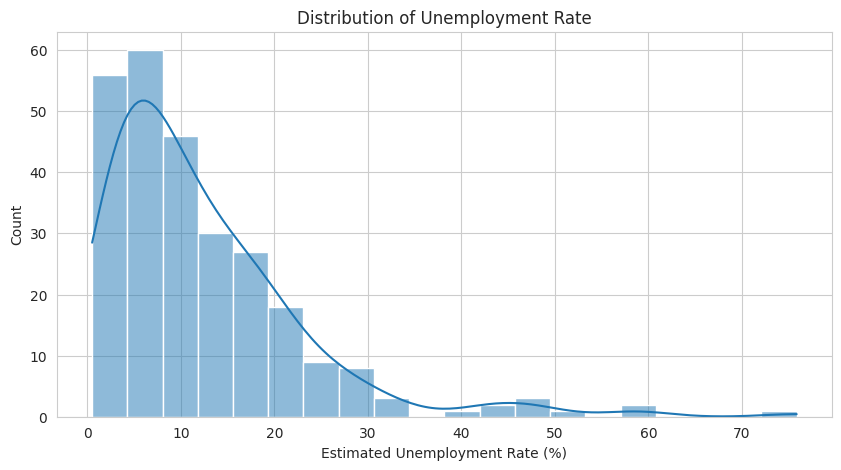

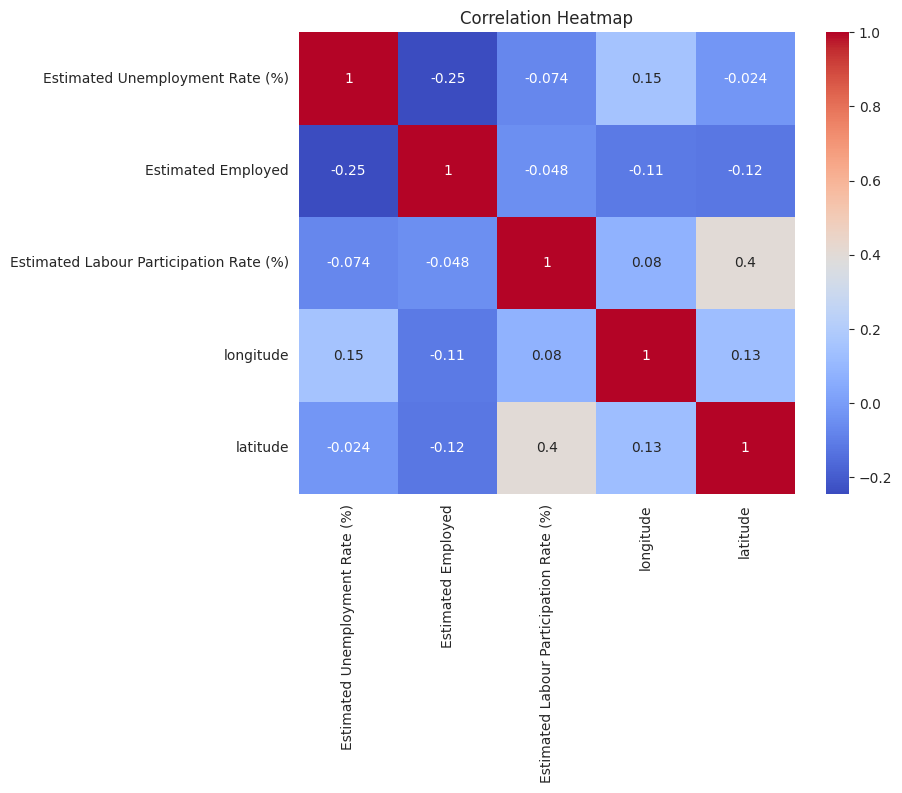

/tmp/ipykernel_771/3506735326.py:118: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(


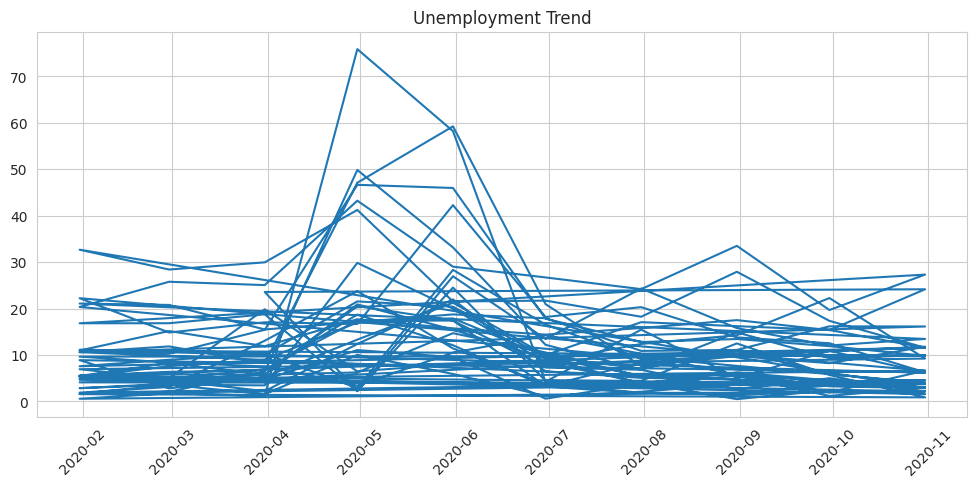


Average Unemployment Rate:
2792452.6

Project Completed Successfully


In [2]:
# ==========================
# TASK 2: Unemployment Analysis with Python
# (No Manual Upload Needed)
# ==========================

# Install Kaggle
!pip install -q kaggle

# Upload kaggle.json
from google.colab import files
print("Upload kaggle.json file")
files.upload()

# Configure Kaggle
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d gokulrajkmv/unemployment-in-india

# Extract ZIP
import zipfile

zip_path = "unemployment-in-india.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall()

print("Dataset Extracted Successfully")

# List files
import os
print("\nFiles:")
print(os.listdir())

# Load CSV
import pandas as pd

csv_file = [f for f in os.listdir() if f.endswith(".csv")][0]

df = pd.read_csv(csv_file)

# Preview
print("\nFirst 5 Rows:")
display(df.head())

# Dataset Information
print("\nDataset Info")
df.info()

# Missing Values
print("\nMissing Values")
print(df.isnull().sum())

# Remove missing values
df = df.dropna()

# Clean column names
df.columns = df.columns.str.strip()

# Summary
print("\nStatistics")
display(df.describe())

# --------------------------
# Visualizations
# --------------------------

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Histogram
numeric = df.select_dtypes(include="number")

if len(numeric.columns) > 0:

    plt.figure(figsize=(10,5))

    sns.histplot(
        numeric.iloc[:,0],
        bins=20,
        kde=True
    )

    plt.title("Distribution of Unemployment Rate")

    plt.show()

# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

# Line Plot (Date if available)

date_cols = [
    c for c in df.columns
    if "date" in c.lower()
]

if len(date_cols) > 0:

    date_col = date_cols[0]

    df[date_col] = pd.to_datetime(
        df[date_col],
        errors="coerce"
    )

    value_col = numeric.columns[0]

    plt.figure(figsize=(12,5))

    plt.plot(
        df[date_col],
        df[value_col]
    )

    plt.title("Unemployment Trend")

    plt.xticks(rotation=45)

    plt.show()

# Average Rate
avg = numeric.mean().mean()

print("\nAverage Unemployment Rate:")
print(round(avg, 2))

print("\nProject Completed Successfully")